In [15]:
import os, json, re, torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset

os.environ["TORCH_COMPILE_DISABLE"] = "1"

# ── 1. Configuration ──
BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
CHAT_TEMPLATE = "llama-3.1"
SFT_ADAPTER = "./outputs/cfo/checkpoint-50"          # The adapter you just trained!
OUTPUT_DIR = "outputs/cfo_rl"        # Where the final RL brain goes
TRANSITIONS_PATH = "/teamspace/studios/this_studio/Cashflowmanager/transitions.jsonl"

In [16]:
if not os.path.exists(TRANSITIONS_PATH):
    print("Generating RL transitions from environment (this takes a moment)...")
    os.system("python3 scripts/generate_rl_transitions.py")

def load_transitions(path):
    prompts = []
    with open(path) as f:
        for line in f:
            t = json.loads(line.strip())
            advisor_str = '\n'.join([f'[{k}]: {json.dumps(v)}' for k, v in t.get('advisor_memos', {}).items()])
            prompt_text = f"State: {t['state_summary']}\nAdvisors:\n{advisor_str}\nDecide the best action (pay/defer/negotiate/credit):"
            prompts.append({'prompt': [{'role': 'user', 'content': prompt_text}], 'reward': t['reward'], 'action': t['action']})
    return prompts

raw_data = load_transitions(TRANSITIONS_PATH)
dataset = Dataset.from_list([{
    'prompt': d['prompt'], 
    'expert_type': d['action'].get('type', ''),
    'env_reward': d['reward']
} for d in raw_data])
print(f"Loaded {len(raw_data)} transitions for GRPO")

Loaded 3000 transitions for GRPO


In [17]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from peft import PeftModel

print("Loading Base Llama Model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=1024,
    dtype=None,
    load_in_4bit=True,
)
tokenizer = get_chat_template(tokenizer, chat_template=CHAT_TEMPLATE)
if tokenizer.pad_token is None: 
    tokenizer.pad_token = tokenizer.eos_token

print("Attaching SFT Adapter and preparing for RL...")
# Load your SFT adapter so it knows HOW to format JSON
model.load_adapter(SFT_ADAPTER)

# Re-wrap it so GRPO can train it further
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

Loading Base Llama Model...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


Attaching SFT Adapter and preparing for RL...


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [18]:
# ── 4. Define Environment Reward Function ──

# ✅ FIX 2: Correctly accept 'prompts', 'completions', and our new dataset columns
def reward_function(prompts, completions, expert_type, env_reward, **kwargs):
    rewards = []
    
    for i, completion in enumerate(completions):
        score = 0.0
        text = completion[0]["content"] if isinstance(completion[0], dict) else completion[0]
        
        # 1. Format Reward (Did it output JSON?)
        try:
            start = text.find('{')
            end = text.rfind('}') + 1
            parsed = json.loads(text[start:end])
            score += 1.0 
            
            p_type = parsed.get('type')
            if p_type in ['pay','defer','negotiate','credit']: 
                score += 2.0
            
            # 2. Expert Match Reward
            if p_type == expert_type[i]: 
                score += 3.0
        except:
            score -= 3.0 # Harsh penalty for forgetting how to write JSON!
        
        # 3. Environment Simulation Reward
        # We scale down the environment reward slightly so it doesn't overpower the format rewards
        score += env_reward[i] * 0.05 
            
        rewards.append(score)
        
    return rewards


In [19]:
from trl import GRPOConfig, GRPOTrainer
from transformers import TrainerCallback

class RLLogger(TrainerCallback):
    def __init__(self):
        self.rewards, self.steps = [], []
    def on_log(self, args, state, control, logs=None, **kwargs):
        # TRL logs reward as 'reward' or 'rewards/mean'
        rew = logs.get("reward", logs.get("rewards/mean"))
        if rew is not None:
            self.rewards.append(rew)
            self.steps.append(state.global_step)

logger = RLLogger()
grpo_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_generations=4,           # Number of paths it explores per prompt
    max_prompt_length=768,
    max_completion_length=256,
    max_steps=60,                # Keep it short for the hackathon (takes ~15 mins)
    learning_rate=5e-6,
    logging_steps=5,
    optim="adamw_8bit",
    report_to="none"
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    args=grpo_args,
    train_dataset=dataset,
    reward_funcs=[reward_function],
    callbacks=[logger]
)

print("\n🚀 Starting RL (GRPO) Training...")
trainer.train()


🚀 Starting RL (GRPO) Training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 48,627,712 of 3,261,377,536 (1.49% trained)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Future

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_function / mean,rewards / reward_function / std
5,0.000000,-1599.367616,0.000000,238.950000,192.000000,256.000000,0.550000,219.650000,192.000000,240.800000,0.000010,-1599.367616,1084.300986
10,0.000000,-539.444961,0.000000,229.425000,156.000000,256.000000,0.600000,180.900000,156.000000,204.200000,0.000010,-539.444961,572.994221
15,0.000000,-1024.025628,0.000000,231.125000,155.600000,256.000000,0.550000,207.500000,155.600000,246.200000,0.000010,-1024.025628,1091.430442
20,0.000000,-673.845727,0.000000,241.450000,169.200000,256.000000,0.700000,205.450000,169.200000,236.400000,0.000011,-673.845727,696.706049
25,0.000000,-2043.078240,0.000000,228.400000,146.800000,256.000000,0.600000,183.350000,146.800000,219.200000,0.000011,-2043.078240,1234.782227
30,0.000000,-1696.266351,0.000000,239.750000,189.400000,256.000000,0.675000,214.106668,189.400000,232.400000,0.000011,-1696.266351,1790.509322
35,0.000000,-404.421697,0.000000,243.900000,185.800000,256.000000,0.800000,158.566669,134.600000,184.800000,0.000011,-404.421697,411.234731
40,0.000000,-1517.531002,0.000000,237.650000,184.600000,256.000000,0.575000,214.273334,184.600000,234.200000,0.000011,-1517.531002,914.117543
45,0.000000,-585.578483,0.000000,235.275000,176.400000,256.000000,0.450000,216.593338,176.400000,241.600000,0.000011,-585.578483,625.746675
50,0.000000,-916.530304,0.000000,232.475000,162.800000,256.000000,0.525000,201.736670,162.800000,234.800000,0.000011,-916.530304,356.347825


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPREC

TrainOutput(global_step=60, training_loss=1.074168007875187e-08, metrics={'train_runtime': 3360.095, 'train_samples_per_second': 0.143, 'train_steps_per_second': 0.018, 'total_flos': 0.0, 'train_loss': 1.074168007875187e-08})

Unsloth: Restored added_tokens_decoder metadata in outputs/cfo_rl/tokenizer_config.json.


Found HuggingFace hub cache directory: /teamspace/studios/this_studio/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:27<00:00, 13.56s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:31<00:00, 15.83s/it]


Unsloth: Merge process complete. Saved to `/teamspace/studios/this_studio/Cashflowmanager/notebooks/outputs/cfo_rl`

✅ RL Adapter successfully saved to outputs/cfo_rl


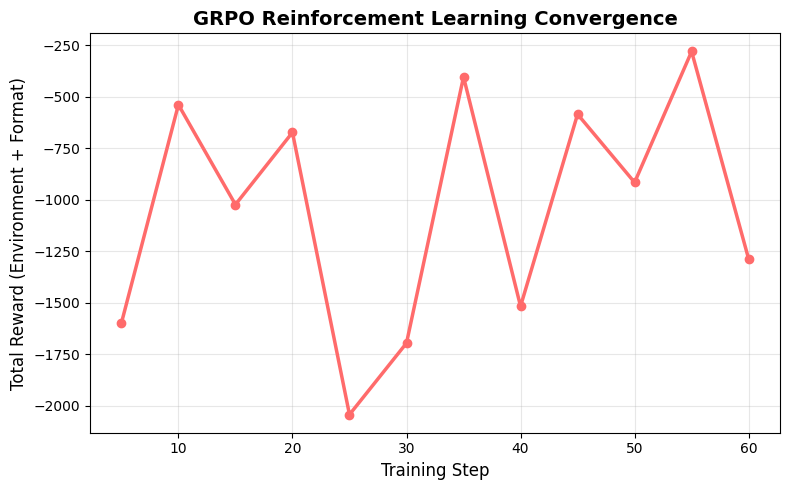

📈 Saved 'rl_reward_curves.png' — Add this to your README!


In [20]:
model.save_pretrained_merged(OUTPUT_DIR, tokenizer, save_method="lora")
print(f"\n✅ RL Adapter successfully saved to {OUTPUT_DIR}")

if logger.rewards:
    plt.figure(figsize=(8, 5))
    plt.plot(logger.steps, logger.rewards, color='#FF6B6B', linewidth=2.5, marker='o')
    plt.title('GRPO Reinforcement Learning Convergence', fontsize=14, fontweight='bold')
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Total Reward (Environment + Format)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('rl_reward_curves.png', dpi=150)
    plt.show()
    print("📈 Saved 'rl_reward_curves.png' — Add this to your README!")

In [9]:
import os, json, torch, gc
from peft import PeftModel
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

os.environ["TORCH_COMPILE_DISABLE"] = "1"
MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
RL_ADAPTER_DIR = "/teamspace/studios/this_studio/Cashflowmanager/notebooks/outputs/cfo/checkpoint-50" 

CFO_SYSTEM = (
    "You are the CFO of a company managing daily cash flow decisions. "
    "Output valid JSON with keys: invoice_id, type (pay|defer|negotiate|credit), "
    "amount, reasoning."
)


TEST_PROMPT = (
    "Day: 2 | Cash: ₹17429 | Credit: ₹0/500000\n\n"
    "ADVISORS:\n"
    "[Expenditure]: [PAY_IMMEDIATELY] Total Debt: ₹929430. Top Priority: a618eaad. Invoice a618eaad has a high penalty cost (₹5759). Pay immediately.\n"
    "[Revenue]: [CASH_CRITICAL] Inflow: ₹1221999. Net Position: ₹-438673. Deficit of ₹438673 expected. Draw credit immediately.\n"
    "[Risk]: [CRITICAL] Credit: 0%. Survival Target: ₹743544. Threats: 1. Overall risk is critical. Survival requires ₹743544 buffer.\n\n"
    "INVOICES:\n"
    "- 37643062: ₹91035 due in 5d\n"
    "- 94c229fc: ₹72799 due in 4d\n"
    "- a618eaad: ₹100188 due in 1d\n"
    "- 28b6dbf4: ₹147868 due in 3d\n"
    "- b1f520b2: ₹208046 due in 2d\n"
    "- f776572f: ₹309494 due in 8d"
)



def get_prediction(is_rl=False):
    print(f"\nLoading {'🟢 RL Trained Model' if is_rl else '🔴 Base Model'}...")
    model, tok = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME, max_seq_length=2048, dtype=None, load_in_4bit=True
    )
    tok = get_chat_template(tok, chat_template="llama-3.1")
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    
    if is_rl:
        # Explicitly attach the RL adapter
        model = PeftModel.from_pretrained(model, RL_ADAPTER_DIR, is_trainable=False)
        
    FastLanguageModel.for_inference(model)
    
    msgs = [{"role": "system", "content": CFO_SYSTEM}, {"role": "user", "content": TEST_PROMPT}]
    inp = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        out = model.generate(input_ids=inp, max_new_tokens=300, do_sample=False, repetition_penalty=1.15, use_cache=True)
    text = tok.decode(out[0][inp.shape[1]:], skip_special_tokens=True).strip()
    
    # Fully delete from memory to prevent overlap
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return text

def print_decision(text, label):
    print(f"\n{label} PREDICTION:")
    try:
        start = text.find('{')
        end = text.rfind('}') + 1
        parsed = json.loads(text[start:end])
        if "invoices" in parsed: parsed = parsed["invoices"][0]
        print(f"➜ Action Taken : {parsed.get('type', 'UNKNOWN').upper()}")
        print(f"➜ Reasoning    : {parsed.get('reasoning', 'None provided')}")
    except:
        print("Raw output:", text)

# Run them cleanly!
base_text = get_prediction(is_rl=False)
rl_text = get_prediction(is_rl=True)

print("\n" + "="*60)
print_decision(base_text, "🔴 BASE MODEL (Untrained)")
print_decision(rl_text, "🟢 TRAINED RL CFO (After GRPO)")
print("="*60)



Loading 🔴 Base Model...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Loading 🟢 RL Trained Model...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




🔴 BASE MODEL (Untrained) PREDICTION:
➜ Action Taken : PAY
➜ Reasoning    : Due soon

🟢 TRAINED RL CFO (After GRPO) PREDICTION:
➜ Action Taken : DEFER
➜ Reasoning    : Deferring payment to maintain liquidity
